# Single-Prompt Generation Comparison

This notebook runs the same SD1.5 implementations as the long COCO experiment on one custom prompt. All methods reuse the exact same initial latent tensor.

In [6]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

# The metric checkpoint stays outside this code repository.
SSCD_MODEL_PATH = Path(os.environ.get(
    'SSCD_MODEL_PATH',
    Path.home() / 'models' / 'sscd_disc_mixup.torchscript.pt',
))
os.environ.setdefault('SSCD_MODEL_PATH', str(SSCD_MODEL_PATH))

# 'sd15' or 'sdxl'. All four methods -- clean_ddim, cads, tpso, rho_star --
# are verified working on sdxl.
MODEL_FAMILY = 'sdxl'

if MODEL_FAMILY == 'sdxl':
    MODEL_ID = str(Path.home() / 'BrushNet' / 'checkpoints' / 'stable-diffusion-xl-base-1.0')
    HEIGHT = WIDTH = 1024
else:
    MODEL_ID = 'stable-diffusion-v1-5/stable-diffusion-v1-5'
    HEIGHT = WIDTH = 512

SELECTED_METHODS = ['clean_ddim', 'cads', 'tpso', 'rho_star']

# SELECTED_METHODS = ['clean_ddim', 'cads']
PROMPT = 'A red fox standing in an autumn forest, photorealistic, highly detailed, 8k'
NEGATIVE_PROMPT = ''

NUM_PARTICLES = 5
DDIM_STEPS = 50
GUIDANCE_SCALE = 7.5
ETA = 0.0
INITIAL_SEED = 12345
ETA_SEED = 20800

PULLBACK_RANK = 40
PULLBACK_ITERATIONS = 1
BASIS_TIMESTEP = 500
PROBE_TIMESTEP = 699
# CANDIDATE_RHOS = [0.10, 0.125, 0.15, 0.175, 0.20, 0.25]
CANDIDATE_RHOS = [1.0,1.25,1.5,1.75,2.0,2.5]
MAX_CLIP_DROP = 0.5

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import torch

from evaluation.metrics import PromptMetrics
from generation import ddim, model
from methods import cads, rho_star, tpso
from methods.adaptive_pullback import sample_adaptive_pullback
from pullback import basis as pullback_basis
from pullback import directions

model.load_model(MODEL_ID, family=MODEL_FAMILY, local_files_only=True)
model.set_unet_particle_batch_size(NUM_PARTICLES)
positive, negative, real_tokens = model.encode_prompt(PROMPT, NEGATIVE_PROMPT)
initial_latents = model.make_initial_latents(
    NUM_PARTICLES, HEIGHT, WIDTH, INITIAL_SEED)
metrics = PromptMetrics()
print('initial latents:', tuple(initial_latents.shape))
print('real prompt tokens:', real_tokens)

Loading pipeline components...:  43%|████▎     | 3/7 [00:00<00:01,  3.85it/s]/home/dehay/BrushNet/src/diffusers/models/lora.py:387: FutureWarning: `LoRACompatibleLinear` is deprecated and will be removed in version 1.0.0. Use of `LoRACompatibleLinear` is deprecated. Please switch to PEFT backend by installing PEFT: `pip install peft`.
  deprecate("LoRACompatibleLinear", "1.0.0", deprecation_message)
/home/dehay/BrushNet/src/diffusers/models/lora.py:300: FutureWarning: `LoRACompatibleConv` is deprecated and will be removed in version 1.0.0. Use of `LoRACompatibleConv` is deprecated. Please switch to PEFT backend by installing PEFT: `pip install peft`.
  deprecate("LoRACompatibleConv", "1.0.0", deprecation_message)
Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  5.59it/s]


initial latents: (5, 4, 128, 128)
real prompt tokens: 19


## Pullback Basis And Particle-Specific Rho

This cell is needed only when `rho_star` is selected. It computes one initial basis, probes all rho candidates at one intermediate timestep, and keeps the CLIP-constrained assignment with the largest pairwise DINO distance.

In [8]:
basis = None
selection = None
if 'rho_star' in SELECTED_METHODS:
    anchor, basis_t, _ = directions.compute_clean_anchor(
        initial_latents[:1], positive, negative, DDIM_STEPS,
        GUIDANCE_SCALE, ETA, ETA_SEED, BASIS_TIMESTEP,
    )
    basis, eigenvalues = pullback_basis.compute_pullback_basis(
        anchor, basis_t, positive, real_tokens,
        rank=PULLBACK_RANK,
        number_of_iterations=PULLBACK_ITERATIONS,
        seed=515,
        finite_difference_epsilon=0.5,
    )
    probe_latents, probe_t, _ = directions.compute_clean_anchor(
        initial_latents, positive, negative, DDIM_STEPS,
        GUIDANCE_SCALE, ETA, ETA_SEED, PROBE_TIMESTEP,
    )
    full_directions = rho_star.make_full_scale_directions(
        basis, positive, real_tokens, NUM_PARTICLES, 'disjoint', 777
    )
    probe = rho_star.probe_rho_candidates(
        probe_latents, probe_t, positive, negative, real_tokens,
        full_directions, [0.0] + CANDIDATE_RHOS, GUIDANCE_SCALE,
        schedule_start=999, schedule_end=500, schedule_power=2.0,
    )
    probe = rho_star.add_clip_dino_probe_features(
        probe, PROMPT, metrics, decode_batch_size=5
    )
    selection = rho_star.select_rho_combination_clip_dino(
        probe, max_clip_drop=MAX_CLIP_DROP,
        selectable_rhos=CANDIDATE_RHOS, search_strategy='beam',
        beam_width=4096, constraint_fallback='minimum_selectable',
    )
    print('eigenvalues:', [round(float(x), 4) for x in eigenvalues[:8]])
    print('selected rhos:', selection['selected_rhos'])

pullback basis: power iteration 1/1


/home/dehay/miniforge3/envs/pullback/lib/python3.10/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


eigenvalues: [0.6303, 0.3527, 0.3298, 0.2726, 0.2577, 0.2021, 0.186, 0.177]
selected rhos: [1.5, 2.5, 1.0, 2.5, 1.5]


## Run Selected Methods

In [9]:
images_by_method = {}

if 'clean_ddim' in SELECTED_METHODS:
    latents = ddim.sample_clean_ddim(
        initial_latents, positive, negative, DDIM_STEPS,
        GUIDANCE_SCALE, ETA, ETA_SEED,
    )
    images_by_method['clean_ddim'] = model.decode_latents(latents)

if 'cads' in SELECTED_METHODS:
    latents = cads.sample_cads(
        initial_latents, positive, negative, DDIM_STEPS,
        GUIDANCE_SCALE, ETA, ETA_SEED, start=900, end=600,
        noise_scale=0.15, psi=1.0, noise_seed=999,
        persistence='fresh', use_rescale=True,
    )
    images_by_method['cads'] = model.decode_latents(latents)

if 'tpso' in SELECTED_METHODS:
    optimized = tpso.optimize_token_offsets(
        PROMPT, NUM_PARTICLES, kappa=0.80, sigma=0.01,
        diversity_weight=1.0, learning_rate=1e-3,
        max_steps=200, min_steps=50, patience=15, seed=3407,
    )
    latents, _ = tpso.sample_tpso(
        initial_latents, positive, negative, optimized,
        DDIM_STEPS, GUIDANCE_SCALE, ETA, ETA_SEED, ratio=0.4,
    )
    images_by_method['tpso'] = model.decode_latents(latents)

if 'rho_star' in SELECTED_METHODS:
    latents, pullback_details = sample_adaptive_pullback(
        initial_latents, positive, negative, real_tokens, basis,
        DDIM_STEPS, GUIDANCE_SCALE, ETA, ETA_SEED,
        particle_rho=selection['selected_rhos'],
        start=999, end=500, schedule_power=2.0, mode='disjoint',
        direction_seed=777, number_of_refreshes=2,
        intermediate_rank=20, intermediate_iterations=1,
        intermediate_seed=1515, transition_steps=1,
        finite_difference_epsilon=0.5,
    )
    images_by_method['rho_star'] = model.decode_latents(latents)

TPSO 001/200: joint=1.9500 clean_cos=1.0000 pair_cos=1.0000
TPSO 010/200: joint=0.6774 clean_cos=0.7906 pair_cos=0.6623
TPSO 020/200: joint=0.6157 clean_cos=0.7872 pair_cos=0.5995
TPSO 030/200: joint=0.5821 clean_cos=0.7910 pair_cos=0.5733
TPSO 040/200: joint=0.5747 clean_cos=0.7956 pair_cos=0.5678
TPSO 050/200: joint=0.5615 clean_cos=0.7929 pair_cos=0.5549
TPSO 060/200: joint=0.5574 clean_cos=0.7961 pair_cos=0.5569
TPSO 070/200: joint=0.5525 clean_cos=0.7933 pair_cos=0.5490
TPSO 080/200: joint=0.5496 clean_cos=0.7872 pair_cos=0.5354
TPSO 090/200: joint=0.5421 clean_cos=0.7893 pair_cos=0.5377
TPSO 100/200: joint=0.5503 clean_cos=0.7888 pair_cos=0.5357
TPSO 110/200: joint=0.5494 clean_cos=0.7902 pair_cos=0.5378
TPSO 120/200: joint=0.5542 clean_cos=0.7920 pair_cos=0.5408
TPSO 130/200: joint=0.5518 clean_cos=0.7942 pair_cos=0.5447
TPSO 140/200: joint=0.5481 clean_cos=0.7931 pair_cos=0.5418
TPSO 150/200: joint=0.5396 clean_cos=0.7917 pair_cos=0.5386
TPSO 160/200: joint=0.5396 clean_cos=0.7

adaptive pullback:  14%|█▍        | 7/50 [00:03<00:20,  2.13it/s]

refreshing rank-20 basis at t=841
refresh t=841: power iteration 1/1


adaptive pullback:  32%|███▏      | 16/50 [00:24<00:26,  1.30it/s]

refreshing rank-20 basis at t=661
refresh t=661: power iteration 1/1


,method,clip,dino_sim_mean,dino_sim_max,mss,vendi
0,clean_ddim,36.013470,0.930722,0.964402,0.551448,3.620669
1,cads,35.399445,0.910808,0.937809,0.461530,4.182238
2,tpso,35.694050,0.946767,0.963267,0.555377,3.602562
3,rho_star,35.388767,0.882601,0.951876,0.475206,4.101226


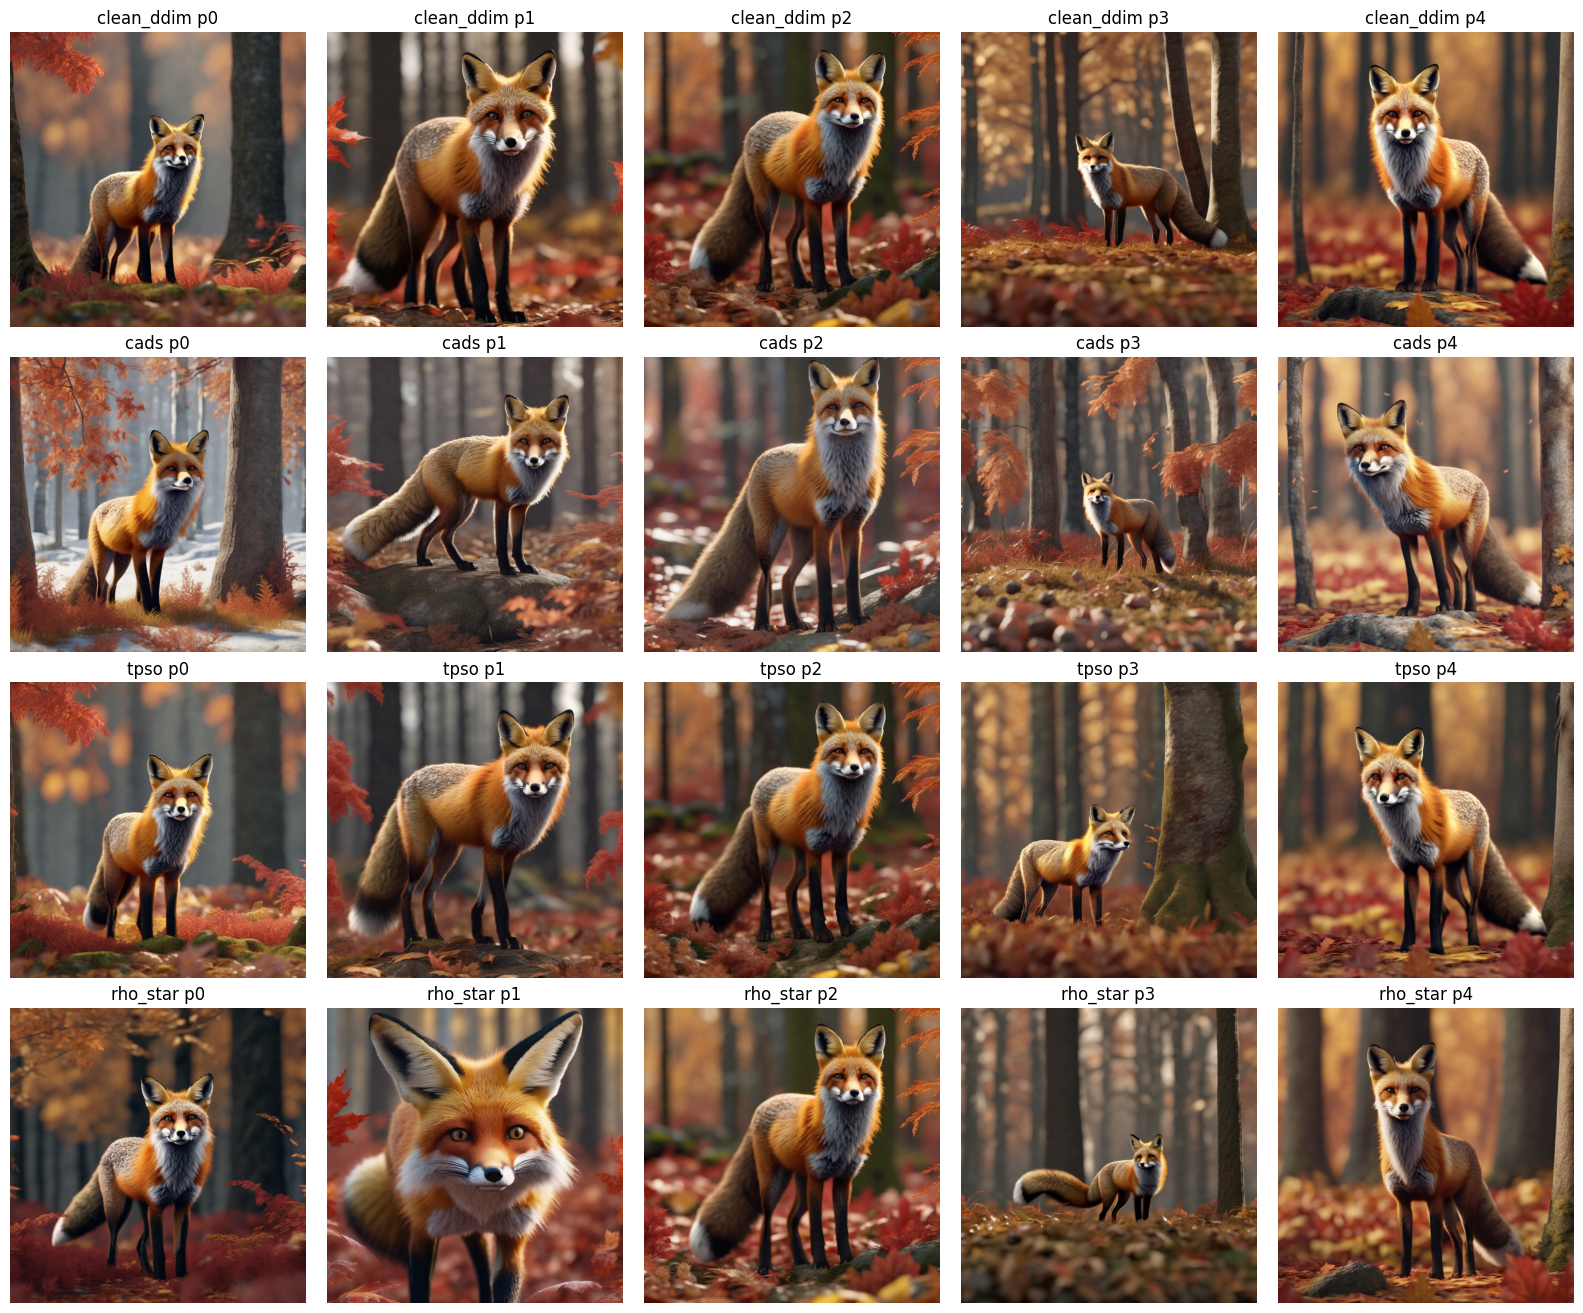

: 

In [ ]:
rows = []
for method_name, images in images_by_method.items():
    values, _ = metrics.compute(images, PROMPT)
    rows.append({'method': method_name, **values})
display(pd.DataFrame(rows)[
    ['method', 'clip', 'dino_sim_mean', 'dino_sim_max', 'mss', 'vendi']
])

fig, axes = plt.subplots(
    len(images_by_method), NUM_PARTICLES,
    figsize=(3.2 * NUM_PARTICLES, 3.3 * len(images_by_method)),
    squeeze=False,
)
for row, (method_name, images) in enumerate(images_by_method.items()):
    for particle, image in enumerate(images):
        axes[row, particle].imshow(image)
        axes[row, particle].set_title(f'{method_name} p{particle}')
        axes[row, particle].axis('off')
plt.tight_layout()
plt.show()